# Photo → diffusion vs. pattern-forming instability

A minimal notebook for testing a science-festival idea.

We start from the **same grayscale photograph** and evolve it in two different ways:

### 1. Ordinary diffusion
$$
\partial_t u = D\nabla^2u.
$$

Diffusion smooths the image until spatial structure disappears.

### 2. Reduced one-field activator–inhibitor model
$$
\partial_t u =
r\,u-u^3+
\gamma\left(G_{\sigma_a}*u-G_{\sigma_i}*u\right),
\qquad \sigma_i>\sigma_a.
$$

Here $G_\sigma*u$ is a Gaussian blur. The narrow Gaussian acts over a short range and the broad Gaussian over a longer range. Their competition amplifies a **finite spatial scale**, while the cubic term saturates the growth.

This is deliberately a **minimal reduced pattern-forming model**, not a literal two-species Turing reaction–diffusion system. It captures the same pedagogical idea of finite-wavelength pattern selection with only one evolving image.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from skimage import data, transform

plt.rcParams["figure.figsize"] = (5, 5)


## 1. Load a stock image

`scikit-image` includes several sample images, so no external files are needed.

Try `"camera"`, `"coins"` or `"moon"`.


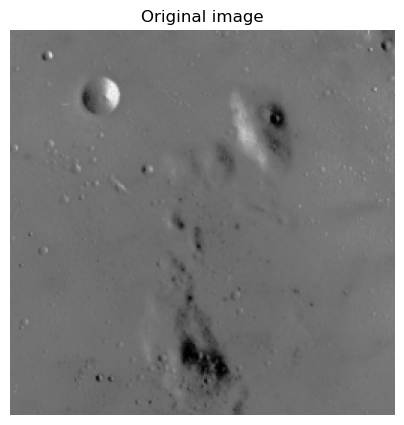

In [4]:
IMAGE = "moon"
SIZE = 256   # 256 is fast enough for interactive experimentation


def load_stock_image(name="camera", size=256):
    images = {
        "camera": data.camera,
        "coins": data.coins,
        "moon": data.moon,
    }

    if name not in images:
        raise ValueError(f"Choose one of: {list(images)}")

    img = images[name]().astype(np.float32)
    img -= img.min()
    img /= max(img.max(), 1e-12)

    img = transform.resize(
        img,
        (size, size),
        anti_aliasing=True,
        preserve_range=True,
    ).astype(np.float32)

    return img


img = load_stock_image(IMAGE, SIZE)

plt.imshow(img, cmap="gray", vmin=0, vmax=1)
plt.title("Original image")
plt.axis("off");


In [13]:
#### LOAD CUSTOM IMAGE

PATH = "/home/pablo-perez/Pictures/thoma_lecuit.webp"  # Replace with your image path

def load_custom_image(path, size=256):
    img = plt.imread(path).astype(np.float32)
    if img.ndim == 3:
        img = img.mean(axis=-1)  # Convert to grayscale

    img -= img.min()
    img /= max(img.max(), 1e-12)

    img = transform.resize(
        img,
        (size, size),
        anti_aliasing=True,
        preserve_range=True,
    ).astype(np.float32)

    return img

img = load_custom_image(PATH, SIZE)

## 2. Ordinary diffusion

For the heat equation, the exact solution after time \(t\) is a Gaussian convolution,

$$
u(\mathbf r,t)=G_{\sqrt{2Dt}}*u(\mathbf r,0).
$$

So we do **not** need a time-stepping loop here. This is both simpler and faster.


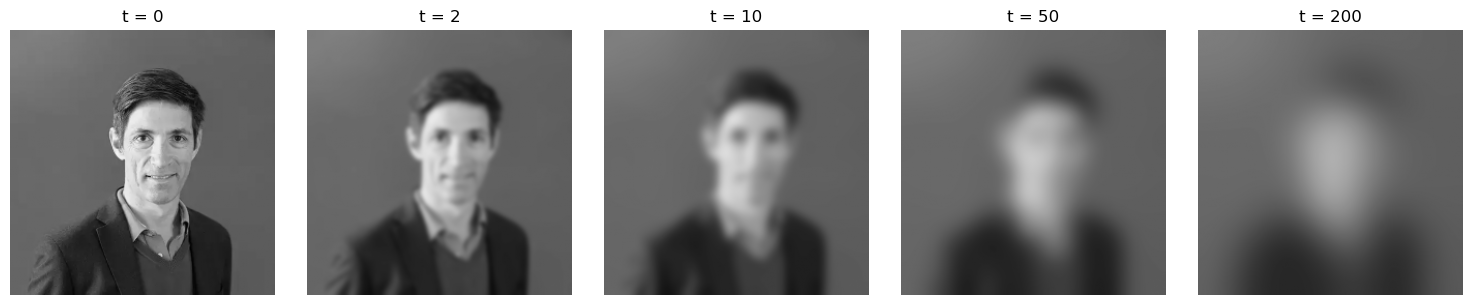

In [14]:
def diffuse_image(img, times, D=1.0):
    out = []
    for t in times:
        sigma = np.sqrt(2.0 * D * t)
        if sigma == 0:
            out.append(img.copy())
        else:
            out.append(
                gaussian_filter(img, sigma=sigma, mode="reflect")
            )
    return out


diff_times = [0, 2, 10, 50, 200]
diffusion_frames = diffuse_image(img, diff_times, D=1.0)

fig, axes = plt.subplots(1, len(diffusion_frames), figsize=(15, 3))
for ax, frame, t in zip(axes, diffusion_frames, diff_times):
    ax.imshow(frame, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"t = {t}")
    ax.axis("off")
plt.tight_layout()


## 3. Reduced one-field pattern model

The evolving field is centered around zero. The photograph is used only as the **initial condition**.

$$
\partial_t u =
r u-u^3+
\gamma
\left(
G_{\sigma_a}*u-G_{\sigma_i}*u
\right).
$$

A useful interpretation is

$$
\text{local activation}
-
\text{longer-range inhibition}.
$$

The parameters below are chosen to produce a labyrinth-like pattern quickly on a \(256\times256\) image.


In [15]:
# ---- Main parameters to play with ----

DT = 0.20
N_STEPS = 300

R = -0.15
GAMMA = 1.20

SIGMA_ACT = 2.0
SIGMA_INH = 4.0

CUBIC = 1.0

SNAPSHOT_STEPS = [0, 10, 50, 150, 300]


In [16]:
def prepare_initial_field(img, amplitude=0.15):
    u = img.astype(np.float32).copy()

    # Center and normalize so the dynamics does not depend strongly
    # on the original image brightness/contrast.
    u -= u.mean()
    u /= max(u.std(), 1e-6)
    u *= amplitude

    return u


def evolve_pattern(
    u0,
    n_steps=300,
    dt=0.20,
    r=-0.15,
    gamma=1.20,
    sigma_act=1.0,
    sigma_inh=4.0,
    cubic=1.0,
    snapshot_steps=(0, 10, 50, 150, 300),
):
    u = np.asarray(u0, dtype=np.float32).copy()
    wanted = set(snapshot_steps)
    snapshots = {}

    for step in range(n_steps + 1):
        if step in wanted:
            snapshots[step] = u.copy()

        if step == n_steps:
            break

        short_range = gaussian_filter(u, sigma=sigma_act, mode="wrap")
        long_range  = gaussian_filter(u, sigma=sigma_inh, mode="wrap")

        du = (
            r * u
            - cubic * u**3
            + gamma * (short_range - long_range)
        )

        u += dt * du

    return snapshots


u0 = prepare_initial_field(img)

pattern_frames = evolve_pattern(
    u0,
    n_steps=N_STEPS,
    dt=DT,
    r=R,
    gamma=GAMMA,
    sigma_act=SIGMA_ACT,
    sigma_inh=SIGMA_INH,
    cubic=CUBIC,
    snapshot_steps=SNAPSHOT_STEPS,
)


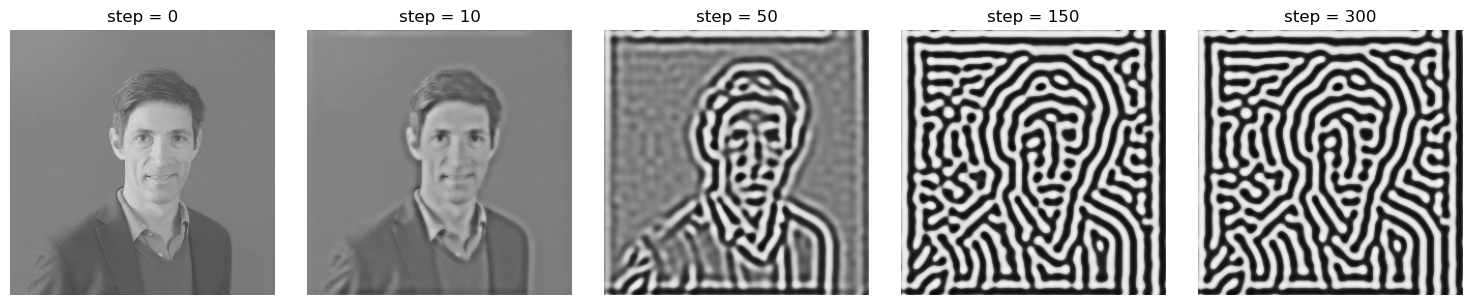

In [17]:
# Symmetric color scale for the pattern field
vmax = max(np.max(np.abs(frame)) for frame in pattern_frames.values())

fig, axes = plt.subplots(1, len(pattern_frames), figsize=(15, 3))

for ax, (step, frame) in zip(axes, pattern_frames.items()):
    ax.imshow(frame, cmap="gray", vmin=-vmax, vmax=vmax)
    ax.set_title(f"step = {step}")
    ax.axis("off")

plt.tight_layout()


## 4. Festival-style comparison

The important point is that both panels begin from the **same photograph**.

- Left: diffusion removes spatial structure.
- Right: a finite-wavelength instability selects a characteristic pattern scale.


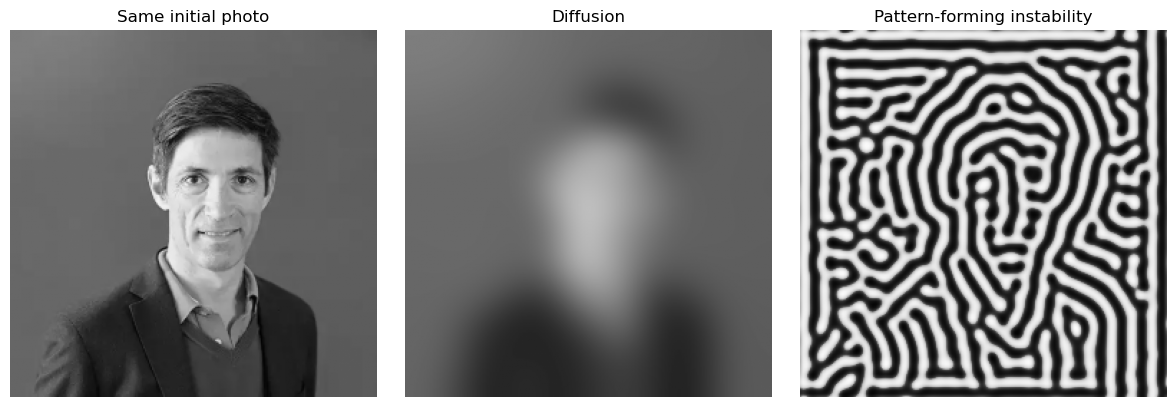

In [18]:
# Choose a diffusion time that visibly destroys the image.
blurred = diffuse_image(img, [100], D=1.0)[0]

final_pattern = pattern_frames[N_STEPS]
pmax = np.max(np.abs(final_pattern))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Same initial photo")

axes[1].imshow(blurred, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Diffusion")

axes[2].imshow(final_pattern, cmap="gray", vmin=-pmax, vmax=pmax)
axes[2].set_title("Pattern-forming instability")

for ax in axes:
    ax.axis("off")

plt.tight_layout()


## 5. Parameter exploration

For a future GUI, these are the natural controls:

- `SIGMA_INH / SIGMA_ACT`: ratio of interaction ranges.
- `GAMMA`: strength of the activation/inhibition competition.
- `R`: background linear growth/decay.
- `DT`: numerical time step.
- `N_STEPS`: evolution time.

A particularly intuitive public-facing control is **pattern size**. Increasing both Gaussian widths while keeping their ratio similar produces coarser structures.

Try, for example:

```python
SIGMA_ACT = 2.0
SIGMA_INH = 8.0
```

instead of

```python
SIGMA_ACT = 1.0
SIGMA_INH = 4.0
```

### Important scientific caveat

This notebook is a reduced phenomenological model. If the exhibit is explicitly presented as a **Turing reaction–diffusion system**, a two-field activator–inhibitor PDE should be shown somewhere in the explanation.

For the public-facing demonstration, however, this one-field version has a useful interpretation:

$$
\boxed{\text{short-range activation}}
-
\boxed{\text{long-range inhibition}}
\rightarrow
\boxed{\text{selected spatial scale}}
$$


## 6. Optional binary rendering

For a stronger black/white graphical effect, threshold the final field. This changes only the visualization, not the dynamics.


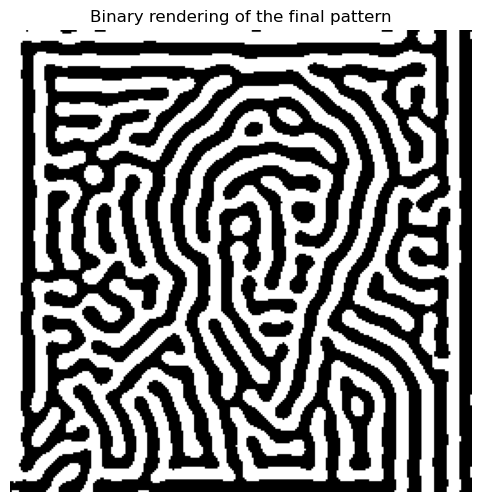

In [19]:
binary = final_pattern > 0

plt.figure(figsize=(6, 6))
plt.imshow(binary, cmap="gray")
plt.title("Binary rendering of the final pattern")
plt.axis("off");
